# 超参数调优：Grid Search 与 Random Search

本 notebook 使用 `predictive_maintenance.csv` 演示两种常用超参数搜索方法：

- **Grid Search**：网格搜索，穷举给定参数组合；
- **Random Search**：随机搜索，从参数空间中随机抽取若干组合。

示例模型使用 LightGBM，并结合：

- `Pipeline`：统一预处理和建模，避免泄露；
- `StratifiedKFold`：处理类别不平衡；
- 独立测试集：最终评估搜索到的最佳模型。

## 数据集说明

目标变量：

- `Machine failure`：`1` 表示设备故障，`0` 表示正常。

输入特征：

- `Type`：设备类型；
- `Air temperature`：空气温度；
- `Process temperature`：过程温度；
- `Rotational speed`：转速；
- `Torque`：扭矩；
- `Tool wear`：刀具磨损。

`TWF`、`HDF`、`PWF`、`OSF`、`RNF` 是故障原因/故障模式指示变量，直接使用会造成标签泄露，因此不作为输入特征。

## 1. 超参数调优的核心思想

机器学习模型有两类参数：

- **模型参数**：训练过程中自动学习，例如线性回归的系数；
- **超参数**：训练前由人工设置，例如学习率、树深度、叶子数量、KNN 的 K。

超参数会直接影响模型复杂度、训练速度和泛化能力，因此通常需要通过验证集或交叉验证进行选择。

### Grid Search

Grid Search 会穷举所有给定参数组合。例如：

- `num_leaves`: `[7, 15, 31]`
- `learning_rate`: `[0.05, 0.1]`
- `min_child_samples`: `[10, 20]`

一共会尝试 `3 × 2 × 2 = 12` 种组合。

优点：系统、全面，适合参数空间较小的情况。  
缺点：参数数量和取值一多，组合数量会指数增长，计算成本很高。

### Random Search

Random Search 不穷举所有组合，而是在更大的参数空间中随机抽取 `n_iter` 组参数进行试验。

优点：

- 在相同计算预算下，可以探索每个参数的更多取值；
- 更适合高维、连续型参数空间；
- 实践中常常能用更少试验找到较好的参数。

缺点：结果是随机的，不保证覆盖所有重要组合；需要固定 `random_state` 以便复现。

## 2. 导入库

In [1]:
from pathlib import Path

import warnings

import lightgbm as lgb
import matplotlib.pyplot as plt
import pandas as pd
import seaborn as sns
from sklearn.compose import ColumnTransformer
from sklearn.metrics import (
    ConfusionMatrixDisplay,
    classification_report,
    f1_score,
    precision_score,
    recall_score,
)
from sklearn.model_selection import (
    GridSearchCV,
    RandomizedSearchCV,
    StratifiedKFold,
    train_test_split,
)
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import OneHotEncoder, StandardScaler

warnings.filterwarnings("ignore", message="X does not have valid feature names.*")

## 3. 读取数据

In [2]:
csv_path = Path.cwd() / "predictive_maintenance.csv"

if not csv_path.exists():
    csv_path = Path("Python Guidance/day31-45/predictive_maintenance.csv")

df = pd.read_csv(csv_path)
df.head()

,Type,Air temperature,Process temperature,Rotational speed,Torque,Tool wear,Machine failure,TWF,HDF,PWF,OSF,RNF
0,M,298.1,308.6,1551,42.8,0,0,0,0,0,0,0
1,L,298.2,308.7,1408,46.3,3,0,0,0,0,0,0
2,L,298.1,308.5,1498,49.4,5,0,0,0,0,0,0
3,L,298.2,308.6,1433,39.5,7,0,0,0,0,0,0
4,L,298.2,308.7,1408,40.0,9,0,0,0,0,0,0


## 4. 定义特征和目标变量

In [3]:
target = "Machine failure"
failure_mode_columns = ["TWF", "HDF", "PWF", "OSF", "RNF"]

numeric_features = [
    "Air temperature",
    "Process temperature",
    "Rotational speed",
    "Torque",
    "Tool wear",
]
categorical_features = ["Type"]

X = df[numeric_features + categorical_features]
y = df[target]

## 5. 检查目标变量分布

故障样本只占约 3.4%，因此这里使用分层交叉验证，并以 F1 作为搜索评分。实际业务中也可以把评分换成 Recall 或 Average Precision。

In [4]:
print("数据形状:", df.shape)
print("缺失值数量:", int(df.isna().sum().sum()))
print("\n目标变量分布:")
print(y.value_counts().rename(index={0: "正常", 1: "故障"}))
print(f"\n故障比例: {y.mean():.2%}")

数据形状: (10000, 12)
缺失值数量: 0

目标变量分布:
Machine failure
正常    9661
故障     339
Name: count, dtype: int64

故障比例: 3.39%


## 6. 拆分训练集和测试集

超参数搜索只使用训练集内部进行交叉验证。测试集不参与调参，最后只用于评估搜索得到的模型。

In [5]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42,
    stratify=y,
)

print("训练集:", X_train.shape, f"故障比例 {y_train.mean():.2%}")
print("测试集:", X_test.shape, f"故障比例 {y_test.mean():.2%}")

训练集: (8000, 6) 故障比例 3.39%
测试集: (2000, 6) 故障比例 3.40%


## 7. 建立 Pipeline

Pipeline 中的参数使用 `步骤名__参数名` 的方式指定。例如：

```python
model__learning_rate
```

表示 Pipeline 中名为 `model` 的步骤的 `learning_rate` 参数。

In [6]:
preprocessor = ColumnTransformer(
    transformers=[
        ("num", StandardScaler(), numeric_features),
        (
            "cat",
            OneHotEncoder(handle_unknown="ignore", sparse_output=False),
            categorical_features,
        ),
    ]
)

base_pipeline = Pipeline(
    steps=[
        ("prep", preprocessor),
        (
            "model",
            lgb.LGBMClassifier(
                n_estimators=200,
                objective="binary",
                class_weight="balanced",
                random_state=42,
                n_jobs=-1,
                force_col_wise=True,
                verbosity=-1,
            ),
        ),
    ]
)

cv = StratifiedKFold(
    n_splits=3,
    shuffle=True,
    random_state=42,
)

## 8. Grid Search

下面定义一个较小的网格，方便完整展示穷举搜索过程。

这里共有：

- 3 个 `num_leaves`
- 2 个 `learning_rate`
- 2 个 `min_child_samples`

因此总共会训练并验证 `3 × 2 × 2 = 12` 组参数；每组再进行 3-Fold 交叉验证。

In [7]:
param_grid = {
    "model__num_leaves": [7, 15, 31],
    "model__learning_rate": [0.05, 0.1],
    "model__min_child_samples": [10, 20],
}

grid_search = GridSearchCV(
    estimator=base_pipeline,
    param_grid=param_grid,
    scoring="f1",
    cv=cv,
    n_jobs=1,
    refit=True,
    return_train_score=True,
    verbose=0,
)

grid_search.fit(X_train, y_train)

/home/ahao/miniconda3/envs/ml-industrial/lib/python3.11/site-packages/sklearn/utils/validation.py:2827: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(
/home/ahao/miniconda3/envs/ml-industrial/lib/python3.11/site-packages/sklearn/utils/validation.py:2827: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(
/home/ahao/miniconda3/envs/ml-industrial/lib/python3.11/site-packages/sklearn/utils/validation.py:2827: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(
/home/ahao/miniconda3/envs/ml-industrial/lib/python3.11/site-packages/sklearn/utils/validation.py:2827: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(
/home/ahao/miniconda3/envs/ml-industrial/lib/python3.11/site-packages/sklearn/utils/validation.py:2827: UserWarning: X d

/home/ahao/miniconda3/envs/ml-industrial/lib/python3.11/site-packages/sklearn/utils/validation.py:2827: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(
/home/ahao/miniconda3/envs/ml-industrial/lib/python3.11/site-packages/sklearn/utils/validation.py:2827: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(
/home/ahao/miniconda3/envs/ml-industrial/lib/python3.11/site-packages/sklearn/utils/validation.py:2827: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(
/home/ahao/miniconda3/envs/ml-industrial/lib/python3.11/site-packages/sklearn/utils/validation.py:2827: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(
/home/ahao/miniconda3/envs/ml-industrial/lib/python3.11/site-packages/sklearn/utils/validation.py:2827: UserWarning: X d

/home/ahao/miniconda3/envs/ml-industrial/lib/python3.11/site-packages/sklearn/utils/validation.py:2827: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(
/home/ahao/miniconda3/envs/ml-industrial/lib/python3.11/site-packages/sklearn/utils/validation.py:2827: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(
/home/ahao/miniconda3/envs/ml-industrial/lib/python3.11/site-packages/sklearn/utils/validation.py:2827: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(
/home/ahao/miniconda3/envs/ml-industrial/lib/python3.11/site-packages/sklearn/utils/validation.py:2827: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(
/home/ahao/miniconda3/envs/ml-industrial/lib/python3.11/site-packages/sklearn/utils/validation.py:2827: UserWarning: X d

/home/ahao/miniconda3/envs/ml-industrial/lib/python3.11/site-packages/sklearn/utils/validation.py:2827: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(
/home/ahao/miniconda3/envs/ml-industrial/lib/python3.11/site-packages/sklearn/utils/validation.py:2827: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(
/home/ahao/miniconda3/envs/ml-industrial/lib/python3.11/site-packages/sklearn/utils/validation.py:2827: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(
/home/ahao/miniconda3/envs/ml-industrial/lib/python3.11/site-packages/sklearn/utils/validation.py:2827: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(
/home/ahao/miniconda3/envs/ml-industrial/lib/python3.11/site-packages/sklearn/utils/validation.py:2827: UserWarning: X d

/home/ahao/miniconda3/envs/ml-industrial/lib/python3.11/site-packages/sklearn/utils/validation.py:2827: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(
/home/ahao/miniconda3/envs/ml-industrial/lib/python3.11/site-packages/sklearn/utils/validation.py:2827: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(
/home/ahao/miniconda3/envs/ml-industrial/lib/python3.11/site-packages/sklearn/utils/validation.py:2827: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(
/home/ahao/miniconda3/envs/ml-industrial/lib/python3.11/site-packages/sklearn/utils/validation.py:2827: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(


/home/ahao/miniconda3/envs/ml-industrial/lib/python3.11/site-packages/sklearn/utils/validation.py:2827: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(
/home/ahao/miniconda3/envs/ml-industrial/lib/python3.11/site-packages/sklearn/utils/validation.py:2827: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(
/home/ahao/miniconda3/envs/ml-industrial/lib/python3.11/site-packages/sklearn/utils/validation.py:2827: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(
/home/ahao/miniconda3/envs/ml-industrial/lib/python3.11/site-packages/sklearn/utils/validation.py:2827: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(
/home/ahao/miniconda3/envs/ml-industrial/lib/python3.11/site-packages/sklearn/utils/validation.py:2827: UserWarning: X d

/home/ahao/miniconda3/envs/ml-industrial/lib/python3.11/site-packages/sklearn/utils/validation.py:2827: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(
/home/ahao/miniconda3/envs/ml-industrial/lib/python3.11/site-packages/sklearn/utils/validation.py:2827: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(
/home/ahao/miniconda3/envs/ml-industrial/lib/python3.11/site-packages/sklearn/utils/validation.py:2827: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(
/home/ahao/miniconda3/envs/ml-industrial/lib/python3.11/site-packages/sklearn/utils/validation.py:2827: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(
/home/ahao/miniconda3/envs/ml-industrial/lib/python3.11/site-packages/sklearn/utils/validation.py:2827: UserWarning: X d

/home/ahao/miniconda3/envs/ml-industrial/lib/python3.11/site-packages/sklearn/utils/validation.py:2827: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(
/home/ahao/miniconda3/envs/ml-industrial/lib/python3.11/site-packages/sklearn/utils/validation.py:2827: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(
/home/ahao/miniconda3/envs/ml-industrial/lib/python3.11/site-packages/sklearn/utils/validation.py:2827: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(
/home/ahao/miniconda3/envs/ml-industrial/lib/python3.11/site-packages/sklearn/utils/validation.py:2827: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(


/home/ahao/miniconda3/envs/ml-industrial/lib/python3.11/site-packages/sklearn/utils/validation.py:2827: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(
/home/ahao/miniconda3/envs/ml-industrial/lib/python3.11/site-packages/sklearn/utils/validation.py:2827: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(
/home/ahao/miniconda3/envs/ml-industrial/lib/python3.11/site-packages/sklearn/utils/validation.py:2827: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(
/home/ahao/miniconda3/envs/ml-industrial/lib/python3.11/site-packages/sklearn/utils/validation.py:2827: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(
/home/ahao/miniconda3/envs/ml-industrial/lib/python3.11/site-packages/sklearn/utils/validation.py:2827: UserWarning: X d

/home/ahao/miniconda3/envs/ml-industrial/lib/python3.11/site-packages/sklearn/utils/validation.py:2827: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(
/home/ahao/miniconda3/envs/ml-industrial/lib/python3.11/site-packages/sklearn/utils/validation.py:2827: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(
/home/ahao/miniconda3/envs/ml-industrial/lib/python3.11/site-packages/sklearn/utils/validation.py:2827: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(
/home/ahao/miniconda3/envs/ml-industrial/lib/python3.11/site-packages/sklearn/utils/validation.py:2827: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(
/home/ahao/miniconda3/envs/ml-industrial/lib/python3.11/site-packages/sklearn/utils/validation.py:2827: UserWarning: X d

/home/ahao/miniconda3/envs/ml-industrial/lib/python3.11/site-packages/sklearn/utils/validation.py:2827: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(
/home/ahao/miniconda3/envs/ml-industrial/lib/python3.11/site-packages/sklearn/utils/validation.py:2827: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(
/home/ahao/miniconda3/envs/ml-industrial/lib/python3.11/site-packages/sklearn/utils/validation.py:2827: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(
/home/ahao/miniconda3/envs/ml-industrial/lib/python3.11/site-packages/sklearn/utils/validation.py:2827: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(


/home/ahao/miniconda3/envs/ml-industrial/lib/python3.11/site-packages/sklearn/utils/validation.py:2827: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(
/home/ahao/miniconda3/envs/ml-industrial/lib/python3.11/site-packages/sklearn/utils/validation.py:2827: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(
/home/ahao/miniconda3/envs/ml-industrial/lib/python3.11/site-packages/sklearn/utils/validation.py:2827: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(
/home/ahao/miniconda3/envs/ml-industrial/lib/python3.11/site-packages/sklearn/utils/validation.py:2827: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(


,"estimator estimator: estimator objectThis is assumed to implement the scikit-learn estimator interface.Either estimator needs to provide a ``score`` function,or ``scoring`` must be passed.",Pipeline(step...rbosity=-1))])
,"param_grid param_grid: dict or list of dictionariesDictionary with parameters names (`str`) as keys and lists ofparameter settings to try as values, or a list of suchdictionaries, in which case the grids spanned by each dictionaryin the list are explored. This enables searching over any sequenceof parameter settings.","{'model__learning_rate': [0.05, 0.1], 'model__min_child_samples': [10, 20], 'model__num_leaves': [7, 15, ...]}"
,"scoring scoring: str, callable, list, tuple or dict, default=NoneStrategy to evaluate the performance of the cross-validated model onthe test set.If `scoring` represents a single score, one can use:- a single string (see :ref:`scoring_string_names`);- a callable (see :ref:`scoring_callable`) that returns a single value;- `None`, the `estimator`'s :ref:`default evaluation criterion <scoring_api_overview>` is used.If `scoring` represents multiple scores, one can use:- a list or tuple of unique strings;- a callable returning a dictionary where the keys are the metric names and the values are the metric scores;- a dictionary with metric names as keys and callables as values.See :ref:`multimetric_grid_search` for an example.",'f1'
,"n_jobs n_jobs: int, default=NoneNumber of jobs to run in parallel.``None`` means 1 unless in a :obj:`joblib.parallel_backend` context.``-1`` means using all processors. See :term:`Glossary <n_jobs>`for more details... versionchanged:: v0.20 `n_jobs` default changed from 1 to None",1
,"cv cv: int, cross-validation generator or an iterable, default=NoneDetermines the cross-validation splitting strategy.Possible inputs for cv are:- None, to use the default 5-fold cross validation,- integer, to specify the number of folds in a `(Stratified)KFold`,- :term:`CV splitter`,- an iterable yielding (train, test) splits as arrays of indices.For integer/None inputs, if the estimator is a classifier and ``y`` iseither binary or multiclass, :class:`StratifiedKFold` is used. In allother cases, :class:`KFold` is used. These splitters are instantiatedwith `shuffle=False` so the splits will be the same across calls.Refer :ref:`User Guide <cross_validation>` for the variouscross-validation strategies that can be used here... versionchanged:: 0.22 ``cv`` default value if None changed from 3-fold to 5-fold.",StratifiedKFo... shuffle=True)
,"return_train_score return_train_score: bool, default=FalseIf ``False``, the ``cv_results_`` attribute will not include trainingscores.Computing training scores is used to get insights on how differentparameter settings impact the overfitting/underfitting trade-off.However computing the scores on the training set can be computationallyexpensive and is not strictly required to select the parameters thatyield the best generalization performance... versionadded:: 0.19.. versionchanged:: 0.21 Default value was changed from ``True`` to ``False``",True
,"refit refit: bool, str, or callable, default=TrueRefit an estimator using the best found parameters on the wholedataset.For multiple metric evaluation, this needs to be a `str` denoting thescorer that would be used to find the best parameters for refittingthe estimator at the end.Where there are considerations other than maximum score inchoosing a best estimator, ``refit`` can be set to a function whichreturns the selected ``best_index_`` given ``cv_results_``. In thatcase, the ``best_estimator_`` and ``best_params_`` will be setaccording to the returned ``best_index_`` while the ``best_score_``attribute will not be available.The refitted estimator is made available at the ``best_estimator_``attribute and permits using ``predict`` directly on this``GridSearchCV`` instance.Also for multiple metric evaluation, the attributes ``best_index_``,``best_score_`` and ``best_params_`` will only be available i

In [8]:
print("Grid Search 最佳参数:")
print(grid_search.best_params_)
print(f"\nGrid Search 最佳交叉验证 F1: {grid_search.best_score_:.4f}")

Grid Search 最佳参数:
{'model__learning_rate': 0.1, 'model__min_child_samples': 10, 'model__num_leaves': 31}

Grid Search 最佳交叉验证 F1: 0.7375


## 9. Random Search

下面定义一个更大的参数空间，但只随机尝试 `n_iter=12` 组参数。

这演示了 Random Search 的特点：不穷举所有组合，而是把有限计算预算分散到更大的参数空间中。

In [9]:
param_distributions = {
    "model__num_leaves": [7, 15, 31, 63],
    "model__learning_rate": [0.03, 0.05, 0.1, 0.2],
    "model__min_child_samples": [5, 10, 20, 40],
    "model__subsample": [0.7, 0.8, 0.9, 1.0],
    "model__colsample_bytree": [0.7, 0.8, 0.9, 1.0],
}

random_search = RandomizedSearchCV(
    estimator=base_pipeline,
    param_distributions=param_distributions,
    n_iter=12,
    scoring="f1",
    cv=cv,
    random_state=42,
    n_jobs=1,
    refit=True,
    return_train_score=True,
    verbose=0,
)

random_search.fit(X_train, y_train)

/home/ahao/miniconda3/envs/ml-industrial/lib/python3.11/site-packages/sklearn/utils/validation.py:2827: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(
/home/ahao/miniconda3/envs/ml-industrial/lib/python3.11/site-packages/sklearn/utils/validation.py:2827: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(
/home/ahao/miniconda3/envs/ml-industrial/lib/python3.11/site-packages/sklearn/utils/validation.py:2827: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(
/home/ahao/miniconda3/envs/ml-industrial/lib/python3.11/site-packages/sklearn/utils/validation.py:2827: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(


/home/ahao/miniconda3/envs/ml-industrial/lib/python3.11/site-packages/sklearn/utils/validation.py:2827: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(
/home/ahao/miniconda3/envs/ml-industrial/lib/python3.11/site-packages/sklearn/utils/validation.py:2827: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(
/home/ahao/miniconda3/envs/ml-industrial/lib/python3.11/site-packages/sklearn/utils/validation.py:2827: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(
/home/ahao/miniconda3/envs/ml-industrial/lib/python3.11/site-packages/sklearn/utils/validation.py:2827: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(
/home/ahao/miniconda3/envs/ml-industrial/lib/python3.11/site-packages/sklearn/utils/validation.py:2827: UserWarning: X d

/home/ahao/miniconda3/envs/ml-industrial/lib/python3.11/site-packages/sklearn/utils/validation.py:2827: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(
/home/ahao/miniconda3/envs/ml-industrial/lib/python3.11/site-packages/sklearn/utils/validation.py:2827: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(
/home/ahao/miniconda3/envs/ml-industrial/lib/python3.11/site-packages/sklearn/utils/validation.py:2827: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(


/home/ahao/miniconda3/envs/ml-industrial/lib/python3.11/site-packages/sklearn/utils/validation.py:2827: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(
/home/ahao/miniconda3/envs/ml-industrial/lib/python3.11/site-packages/sklearn/utils/validation.py:2827: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(
/home/ahao/miniconda3/envs/ml-industrial/lib/python3.11/site-packages/sklearn/utils/validation.py:2827: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(
/home/ahao/miniconda3/envs/ml-industrial/lib/python3.11/site-packages/sklearn/utils/validation.py:2827: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(


/home/ahao/miniconda3/envs/ml-industrial/lib/python3.11/site-packages/sklearn/utils/validation.py:2827: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(
/home/ahao/miniconda3/envs/ml-industrial/lib/python3.11/site-packages/sklearn/utils/validation.py:2827: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(
/home/ahao/miniconda3/envs/ml-industrial/lib/python3.11/site-packages/sklearn/utils/validation.py:2827: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(
/home/ahao/miniconda3/envs/ml-industrial/lib/python3.11/site-packages/sklearn/utils/validation.py:2827: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(


/home/ahao/miniconda3/envs/ml-industrial/lib/python3.11/site-packages/sklearn/utils/validation.py:2827: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(
/home/ahao/miniconda3/envs/ml-industrial/lib/python3.11/site-packages/sklearn/utils/validation.py:2827: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(
/home/ahao/miniconda3/envs/ml-industrial/lib/python3.11/site-packages/sklearn/utils/validation.py:2827: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(
/home/ahao/miniconda3/envs/ml-industrial/lib/python3.11/site-packages/sklearn/utils/validation.py:2827: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(


/home/ahao/miniconda3/envs/ml-industrial/lib/python3.11/site-packages/sklearn/utils/validation.py:2827: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(
/home/ahao/miniconda3/envs/ml-industrial/lib/python3.11/site-packages/sklearn/utils/validation.py:2827: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(
/home/ahao/miniconda3/envs/ml-industrial/lib/python3.11/site-packages/sklearn/utils/validation.py:2827: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(
/home/ahao/miniconda3/envs/ml-industrial/lib/python3.11/site-packages/sklearn/utils/validation.py:2827: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(
/home/ahao/miniconda3/envs/ml-industrial/lib/python3.11/site-packages/sklearn/utils/validation.py:2827: UserWarning: X d

/home/ahao/miniconda3/envs/ml-industrial/lib/python3.11/site-packages/sklearn/utils/validation.py:2827: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(
/home/ahao/miniconda3/envs/ml-industrial/lib/python3.11/site-packages/sklearn/utils/validation.py:2827: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(
/home/ahao/miniconda3/envs/ml-industrial/lib/python3.11/site-packages/sklearn/utils/validation.py:2827: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(


/home/ahao/miniconda3/envs/ml-industrial/lib/python3.11/site-packages/sklearn/utils/validation.py:2827: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(
/home/ahao/miniconda3/envs/ml-industrial/lib/python3.11/site-packages/sklearn/utils/validation.py:2827: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(
/home/ahao/miniconda3/envs/ml-industrial/lib/python3.11/site-packages/sklearn/utils/validation.py:2827: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(
/home/ahao/miniconda3/envs/ml-industrial/lib/python3.11/site-packages/sklearn/utils/validation.py:2827: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(


/home/ahao/miniconda3/envs/ml-industrial/lib/python3.11/site-packages/sklearn/utils/validation.py:2827: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(
/home/ahao/miniconda3/envs/ml-industrial/lib/python3.11/site-packages/sklearn/utils/validation.py:2827: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(
/home/ahao/miniconda3/envs/ml-industrial/lib/python3.11/site-packages/sklearn/utils/validation.py:2827: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(
/home/ahao/miniconda3/envs/ml-industrial/lib/python3.11/site-packages/sklearn/utils/validation.py:2827: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(


/home/ahao/miniconda3/envs/ml-industrial/lib/python3.11/site-packages/sklearn/utils/validation.py:2827: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(
/home/ahao/miniconda3/envs/ml-industrial/lib/python3.11/site-packages/sklearn/utils/validation.py:2827: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(
/home/ahao/miniconda3/envs/ml-industrial/lib/python3.11/site-packages/sklearn/utils/validation.py:2827: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(
/home/ahao/miniconda3/envs/ml-industrial/lib/python3.11/site-packages/sklearn/utils/validation.py:2827: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(


/home/ahao/miniconda3/envs/ml-industrial/lib/python3.11/site-packages/sklearn/utils/validation.py:2827: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(
/home/ahao/miniconda3/envs/ml-industrial/lib/python3.11/site-packages/sklearn/utils/validation.py:2827: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(
/home/ahao/miniconda3/envs/ml-industrial/lib/python3.11/site-packages/sklearn/utils/validation.py:2827: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(
/home/ahao/miniconda3/envs/ml-industrial/lib/python3.11/site-packages/sklearn/utils/validation.py:2827: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(


/home/ahao/miniconda3/envs/ml-industrial/lib/python3.11/site-packages/sklearn/utils/validation.py:2827: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(
/home/ahao/miniconda3/envs/ml-industrial/lib/python3.11/site-packages/sklearn/utils/validation.py:2827: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(
/home/ahao/miniconda3/envs/ml-industrial/lib/python3.11/site-packages/sklearn/utils/validation.py:2827: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(
/home/ahao/miniconda3/envs/ml-industrial/lib/python3.11/site-packages/sklearn/utils/validation.py:2827: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(


/home/ahao/miniconda3/envs/ml-industrial/lib/python3.11/site-packages/sklearn/utils/validation.py:2827: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(
/home/ahao/miniconda3/envs/ml-industrial/lib/python3.11/site-packages/sklearn/utils/validation.py:2827: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(
/home/ahao/miniconda3/envs/ml-industrial/lib/python3.11/site-packages/sklearn/utils/validation.py:2827: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(
/home/ahao/miniconda3/envs/ml-industrial/lib/python3.11/site-packages/sklearn/utils/validation.py:2827: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(


/home/ahao/miniconda3/envs/ml-industrial/lib/python3.11/site-packages/sklearn/utils/validation.py:2827: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(
/home/ahao/miniconda3/envs/ml-industrial/lib/python3.11/site-packages/sklearn/utils/validation.py:2827: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(
/home/ahao/miniconda3/envs/ml-industrial/lib/python3.11/site-packages/sklearn/utils/validation.py:2827: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(
/home/ahao/miniconda3/envs/ml-industrial/lib/python3.11/site-packages/sklearn/utils/validation.py:2827: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(
/home/ahao/miniconda3/envs/ml-industrial/lib/python3.11/site-packages/sklearn/utils/validation.py:2827: UserWarning: X d

/home/ahao/miniconda3/envs/ml-industrial/lib/python3.11/site-packages/sklearn/utils/validation.py:2827: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(
/home/ahao/miniconda3/envs/ml-industrial/lib/python3.11/site-packages/sklearn/utils/validation.py:2827: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(
/home/ahao/miniconda3/envs/ml-industrial/lib/python3.11/site-packages/sklearn/utils/validation.py:2827: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(
/home/ahao/miniconda3/envs/ml-industrial/lib/python3.11/site-packages/sklearn/utils/validation.py:2827: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(
/home/ahao/miniconda3/envs/ml-industrial/lib/python3.11/site-packages/sklearn/utils/validation.py:2827: UserWarning: X d

,"estimator estimator: estimator objectAn object of that type is instantiated for each grid point.This is assumed to implement the scikit-learn estimator interface.Either estimator needs to provide a ``score`` function,or ``scoring`` must be passed.",Pipeline(step...rbosity=-1))])
,"param_distributions param_distributions: dict or list of dictsDictionary with parameters names (`str`) as keys and distributionsor lists of parameters to try. Distributions must provide a ``rvs``method for sampling (such as those from scipy.stats.distributions).If a list is given, it is sampled uniformly.If a list of dicts is given, first a dict is sampled uniformly, andthen a parameter is sampled using that dict as above.","{'model__colsample_bytree': [0.7, 0.8, ...], 'model__learning_rate': [0.03, 0.05, ...], 'model__min_child_samples': [5, 10, ...], 'model__num_leaves': [7, 15, ...], ...}"
,"n_iter n_iter: int, default=10Number of parameter settings that are sampled. n_iter tradesoff runtime vs quality of the solution.",12
,"scoring scoring: str, callable, list, tuple or dict, default=NoneStrategy to evaluate the performance of the cross-validated model onthe test set.If `scoring` represents a single score, one can use:- a single string (see :ref:`scoring_string_names`);- a callable (see :ref:`scoring_callable`) that returns a single value;- `None`, the `estimator`'s :ref:`default evaluation criterion <scoring_api_overview>` is used.If `scoring` represents multiple scores, one can use:- a list or tuple of unique strings;- a callable returning a dictionary where the keys are the metric names and the values are the metric scores;- a dictionary with metric names as keys and callables as values.See :ref:`multimetric_grid_search` for an example.If None, the estimator's score method is used.",'f1'
,"n_jobs n_jobs: int, default=NoneNumber of jobs to run in parallel.``None`` means 1 unless in a :obj:`joblib.parallel_backend` context.``-1`` means using all processors. See :term:`Glossary <n_jobs>`for more details... versionchanged:: v0.20 `n_jobs` default changed from 1 to None",1
,"cv cv: int, cross-validation generator or an iterable, default=NoneDetermines the cross-validation splitting strategy.Possible inputs for cv are:- None, to use the default 5-fold cross validation,- integer, to specify the number of folds in a `(Stratified)KFold`,- :term:`CV splitter`,- an iterable yielding (train, test) splits as arrays of indices.For integer/None inputs, if the estimator is a classifier and ``y`` iseither binary or multiclass, :class:`StratifiedKFold` is used. In allother cases, :class:`KFold` is used. These splitters are instantiatedwith `shuffle=False` so the splits will be the same across calls.Refer :ref:`User Guide <cross_validation>` for the variouscross-validation strategies that can be used here... versionchanged:: 0.22 ``cv`` default value if None changed from 3-fold to 5-fold.",StratifiedKFo... shuffle=True)
,"random_state random_state: int, RandomState instance or None, default=NonePseudo random number generator state used for random uniform samplingfrom lists of possible values instead of scipy.stats distributions.Pass an int for reproducible output across multiplefunction calls.See :term:`Glossary <random_state>`.",42
,"return_train_score return_train_score: bool, default=FalseIf ``False``, the ``cv_results_`` attribute will not include trainingscores.Computing training scores is used to get insights on how differentparameter settings impact the overfitting/underfitting trade-off.However computing the scores on the training set can be computationallyexpensive and is not strictly required to select the parameters thatyield the best generalization performance... versionadded:: 0.19.. versionchanged:: 0.21 Default value was changed from ``True`` to ``False``",True
,"refit refit: bool, str, or callable, default=TrueRefit an estimator using the best found parameters on the wholedataset.For multiple metric evaluation, this needs to be a `str` denoting

In [10]:
print("Random Search 最佳参数:")
print(random_search.best_params_)
print(f"\nRandom Search 最佳交叉验证 F1: {random_search.best_score_:.4f}")

Random Search 最佳参数:
{'model__subsample': 0.9, 'model__num_leaves': 63, 'model__min_child_samples': 10, 'model__learning_rate': 0.2, 'model__colsample_bytree': 0.9}

Random Search 最佳交叉验证 F1: 0.7429


## 10. 在独立测试集上比较两种搜索结果

注意：

- `best_score_` 是训练集内部交叉验证的平均 F1；
- 下面的结果是未参与调参的测试集结果。

两者都重要：前者用于调参选择，后者用于最终评估。

In [11]:
def evaluate_estimator(name, estimator, cv_f1):
    y_pred = estimator.predict(X_test)
    return {
        "method": name,
        "cv_f1": cv_f1,
        "accuracy": float((y_pred == y_test.to_numpy()).mean()),
        "precision": precision_score(y_test, y_pred, zero_division=0),
        "recall": recall_score(y_test, y_pred),
        "f1": f1_score(y_test, y_pred, zero_division=0),
    }


comparison = pd.DataFrame(
    [
        evaluate_estimator("Grid Search", grid_search.best_estimator_, grid_search.best_score_),
        evaluate_estimator("Random Search", random_search.best_estimator_, random_search.best_score_),
    ]
)

comparison.round(4)

/home/ahao/miniconda3/envs/ml-industrial/lib/python3.11/site-packages/sklearn/utils/validation.py:2827: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(
/home/ahao/miniconda3/envs/ml-industrial/lib/python3.11/site-packages/sklearn/utils/validation.py:2827: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(


,method,cv_f1,accuracy,precision,recall,f1
0,Grid Search,0.7375,0.986,0.8125,0.7647,0.7879
1,Random Search,0.7429,0.988,0.8793,0.7500,0.8095


In [12]:
print("Grid Search 最佳模型：测试集分类报告")
print(
    classification_report(
        y_test,
        grid_search.best_estimator_.predict(X_test),
        target_names=["正常", "故障"],
        digits=3,
    )
)

print("Random Search 最佳模型：测试集分类报告")
print(
    classification_report(
        y_test,
        random_search.best_estimator_.predict(X_test),
        target_names=["正常", "故障"],
        digits=3,
    )
)

Grid Search 最佳模型：测试集分类报告
              precision    recall  f1-score   support

          正常      0.992     0.994     0.993      1932
          故障      0.812     0.765     0.788        68

    accuracy                          0.986      2000
   macro avg      0.902     0.879     0.890      2000
weighted avg      0.986     0.986     0.986      2000

Random Search 最佳模型：测试集分类报告
              precision    recall  f1-score   support

          正常      0.991     0.996     0.994      1932
          故障      0.879     0.750     0.810        68

    accuracy                          0.988      2000
   macro avg      0.935     0.873     0.902      2000
weighted avg      0.987     0.988     0.988      2000



/home/ahao/miniconda3/envs/ml-industrial/lib/python3.11/site-packages/sklearn/utils/validation.py:2827: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(
/home/ahao/miniconda3/envs/ml-industrial/lib/python3.11/site-packages/sklearn/utils/validation.py:2827: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(


/home/ahao/miniconda3/envs/ml-industrial/lib/python3.11/site-packages/sklearn/utils/validation.py:2827: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(
/home/ahao/miniconda3/envs/ml-industrial/lib/python3.11/site-packages/sklearn/utils/validation.py:2827: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(
/tmp/ipykernel_9278/4211611905.py:23: UserWarning: Glyph 27491 (\N{CJK UNIFIED IDEOGRAPH-6B63}) missing from current font.
  plt.tight_layout()
/tmp/ipykernel_9278/4211611905.py:23: UserWarning: Glyph 24120 (\N{CJK UNIFIED IDEOGRAPH-5E38}) missing from current font.
  plt.tight_layout()
/tmp/ipykernel_9278/4211611905.py:23: UserWarning: Glyph 25925 (\N{CJK UNIFIED IDEOGRAPH-6545}) missing from current font.
  plt.tight_layout()
/tmp/ipykernel_9278/4211611905.py:23: UserWarning: Glyph 38556 (\N{CJK UNIFIED IDEOGRAPH-969C}) missing from current font.
  plt

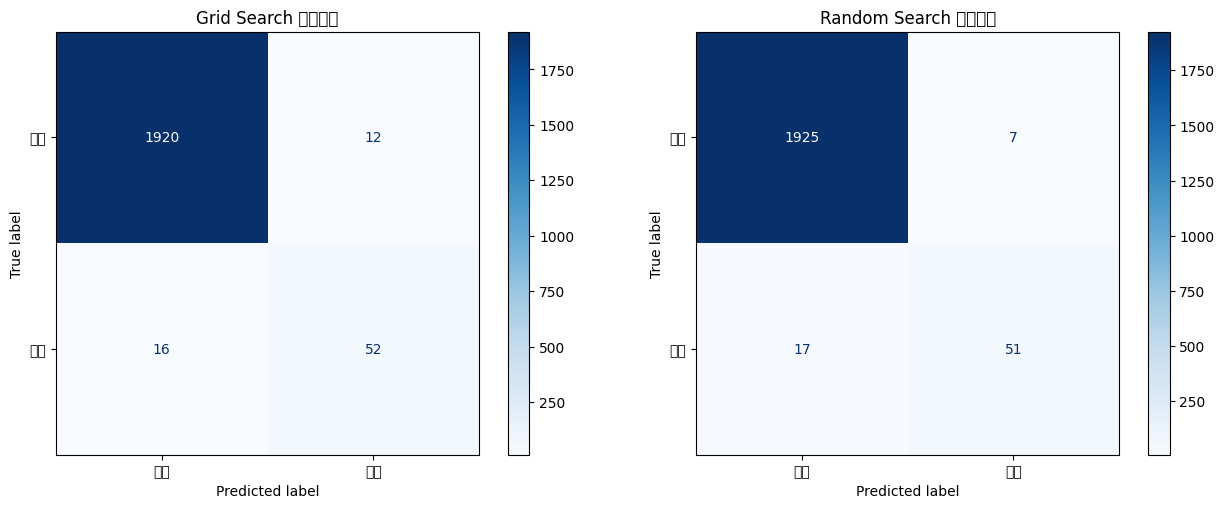

In [13]:
fig, axes = plt.subplots(1, 2, figsize=(13, 5))

ConfusionMatrixDisplay.from_predictions(
    y_test,
    grid_search.best_estimator_.predict(X_test),
    display_labels=["正常", "故障"],
    cmap="Blues",
    values_format="d",
    ax=axes[0],
)
axes[0].set_title("Grid Search 混淆矩阵")

ConfusionMatrixDisplay.from_predictions(
    y_test,
    random_search.best_estimator_.predict(X_test),
    display_labels=["正常", "故障"],
    cmap="Blues",
    values_format="d",
    ax=axes[1],
)
axes[1].set_title("Random Search 混淆矩阵")

plt.tight_layout()
plt.show()

## 11. 查看搜索过程中的候选结果

`cv_results_` 保存了每组参数的交叉验证结果。可以按 `rank_test_score` 查看排名靠前的候选配置。

In [14]:
param_columns = [
    "param_model__num_leaves",
    "param_model__learning_rate",
    "param_model__min_child_samples",
    "param_model__subsample",
    "param_model__colsample_bytree",
]
result_columns = [
    "mean_test_score",
    "std_test_score",
    "rank_test_score",
]

grid_cv_results = pd.DataFrame(grid_search.cv_results_)
random_cv_results = pd.DataFrame(random_search.cv_results_)

grid_param_columns = [c for c in param_columns if c in grid_cv_results.columns]
random_param_columns = [c for c in param_columns if c in random_cv_results.columns]

grid_top = grid_cv_results[grid_param_columns + result_columns].sort_values(
    "rank_test_score"
)
random_top = random_cv_results[random_param_columns + result_columns].sort_values(
    "rank_test_score"
)

print("Grid Search 前 10 组参数：")
display(grid_top.head(10).round(4))

print("Random Search 前 10 组参数：")
display(random_top.head(10).round(4))

Grid Search 前 10 组参数：


,param_model__num_leaves,param_model__learning_rate,param_model__min_child_samples,mean_test_score,std_test_score,rank_test_score
8,31,0.10,10,0.7375,0.0426,1
11,31,0.10,20,0.7298,0.0439,2
2,31,0.05,10,0.7102,0.0246,3
7,15,0.10,10,0.7023,0.0207,4
5,31,0.05,20,0.7011,0.0190,5
10,15,0.10,20,0.6894,0.0252,6
1,15,0.05,10,0.6643,0.0098,7
4,15,0.05,20,0.6432,0.0148,8
9,7,0.10,20,0.6140,0.0273,9
6,7,0.10,10,0.6028,0.0148,10


Random Search 前 10 组参数：


,param_model__num_leaves,param_model__learning_rate,param_model__min_child_samples,param_model__subsample,param_model__colsample_bytree,mean_test_score,std_test_score,rank_test_score
7,63,0.20,10,0.9,0.9,0.7429,0.0290,1
9,31,0.20,5,1.0,0.9,0.7406,0.0391,2
2,63,0.10,40,0.7,0.8,0.7402,0.0353,3
6,63,0.10,40,1.0,0.8,0.7402,0.0353,3
3,63,0.03,10,1.0,0.7,0.7385,0.0319,5
8,63,0.05,5,0.7,0.7,0.7377,0.0394,6
5,31,0.05,5,1.0,0.9,0.7304,0.0103,7
0,63,0.03,5,0.8,0.9,0.7244,0.0381,8
4,31,0.05,20,0.9,0.9,0.7186,0.0240,9
11,15,0.05,5,0.9,0.7,0.6592,0.0113,10


## 12. 可视化搜索结果

- 左侧热图展示 Grid Search 中 `num_leaves` 与 `learning_rate` 对平均 F1 的影响；
- 右侧折线图展示 Random Search 每次随机尝试的交叉验证 F1。

/tmp/ipykernel_9278/1883575036.py:42: UserWarning: Glyph 65306 (\N{FULLWIDTH COLON}) missing from current font.
  plt.tight_layout()
/tmp/ipykernel_9278/1883575036.py:42: UserWarning: Glyph 24179 (\N{CJK UNIFIED IDEOGRAPH-5E73}) missing from current font.
  plt.tight_layout()
/tmp/ipykernel_9278/1883575036.py:42: UserWarning: Glyph 22343 (\N{CJK UNIFIED IDEOGRAPH-5747}) missing from current font.
  plt.tight_layout()
/tmp/ipykernel_9278/1883575036.py:42: UserWarning: Glyph 20132 (\N{CJK UNIFIED IDEOGRAPH-4EA4}) missing from current font.
  plt.tight_layout()
/tmp/ipykernel_9278/1883575036.py:42: UserWarning: Glyph 21449 (\N{CJK UNIFIED IDEOGRAPH-53C9}) missing from current font.
  plt.tight_layout()
/tmp/ipykernel_9278/1883575036.py:42: UserWarning: Glyph 39564 (\N{CJK UNIFIED IDEOGRAPH-9A8C}) missing from current font.
  plt.tight_layout()
/tmp/ipykernel_9278/1883575036.py:42: UserWarning: Glyph 35777 (\N{CJK UNIFIED IDEOGRAPH-8BC1}) missing from current font.
  plt.tight_layout()
/tm

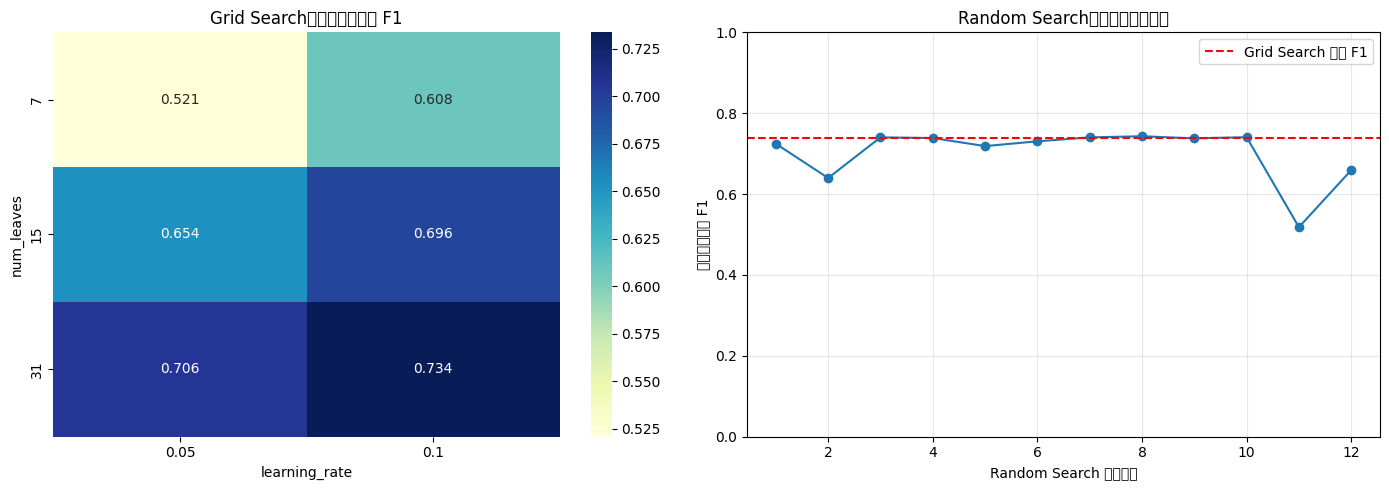

In [15]:
grid_heatmap_data = grid_cv_results.pivot_table(
    index="param_model__num_leaves",
    columns="param_model__learning_rate",
    values="mean_test_score",
    aggfunc="mean",
)

random_plot_data = random_cv_results.copy()
random_plot_data["iteration"] = range(1, len(random_plot_data) + 1)

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

sns.heatmap(
    grid_heatmap_data,
    annot=True,
    fmt=".3f",
    cmap="YlGnBu",
    ax=axes[0],
)
axes[0].set_title("Grid Search：平均交叉验证 F1")
axes[0].set_xlabel("learning_rate")
axes[0].set_ylabel("num_leaves")

axes[1].plot(
    random_plot_data["iteration"],
    random_plot_data["mean_test_score"],
    marker="o",
)
axes[1].axhline(
    grid_search.best_score_,
    color="red",
    linestyle="--",
    label="Grid Search 最佳 F1",
)
axes[1].set_xlabel("Random Search 尝试次数")
axes[1].set_ylabel("平均交叉验证 F1")
axes[1].set_ylim(0, 1.0)
axes[1].grid(True, alpha=0.3)
axes[1].legend()
axes[1].set_title("Random Search：每次尝试的得分")

plt.tight_layout()
plt.show()

## 13. 总结

本 notebook 演示了两种超参数调优方法：

- `GridSearchCV` 会穷举参数网格，适合参数空间较小、希望系统比较的情况；
- `RandomizedSearchCV` 会在更大的参数空间中随机抽样，适合参数较多或部分参数是连续值的情况；
- 两者都应结合交叉验证使用，避免偶然划分影响参数选择；
- `best_score_` 是训练集内部交叉验证分数，最终仍应使用独立测试集评估；
- 在类别不平衡任务中，可以把 `scoring` 设置为 `f1`、`recall` 或 `average_precision`，而不是只看 Accuracy。

## 可以进一步尝试

1. 使用 `RepeatedStratifiedKFold` 提高调参评估稳定性；
2. 使用连续分布进行随机搜索，如对 `learning_rate` 使用对数均匀分布；
3. 尝试贝叶斯优化，如 Optuna；
4. 对阈值也进行搜索，而不是只调模型超参数；
5. 根据漏报/误报业务成本选择评分函数。